# **IMPORTING REQUIRED LIBRARIES AND DOWNLOADING DATASET**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
path = f"{kagglehub.dataset_download("camnugent/california-housing-prices")}/housing.csv"
df = pd.read_csv(path)
df.head()

Using Colab cache for faster access to the 'california-housing-prices' dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# **Data Cleaning**

In [ ]:
print(df.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# **Splitting Training And Test Data**

In [ ]:
numeric_features=df.drop('median_house_value', axis=1).select_dtypes(include=['number']).columns

categorical_features=df.select_dtypes(include=['object', 'category']).columns

In [ ]:
X=df.drop('median_house_value', axis=1)
y=df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# **Preprocessing Step**

In [ ]:
numeric_pipe = Pipeline(steps=[
    ('scale', QuantileTransformer(output_distribution="normal", random_state=42, n_quantiles=1000))
])
categorical_pipe = Pipeline([
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ]
)

# **Model Using Linear Regression**

In [ ]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('Regression', LinearRegression())
])
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)
print("\nMAE", mae, "\nRMSE", rmse, "\nR2", r2)


MAE 53611.76072809314 
RMSE 71585.14466090307 
R2 0.6212211541456273


# **Model Using Ridge**

In [ ]:
model2 = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('Regression', Ridge())
])
model2.fit(X_train, y_train)
predictions = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, predictions)
rmse2 = mean_squared_error(y_test, predictions) ** 0.5
r22 = r2_score(y_test, predictions)
print("\nMAE", mae2, "\nRMSE", rmse2, "\nR2", r22)


MAE 53598.32715561008 
RMSE 71559.10105708633 
R2 0.6214967133214141


# **Model Using Polynomial Regression**

In [ ]:
model3 = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
    ('Regression', LinearRegression())
])
model3.fit(X_train, y_train)
predictions = model3.predict(X_test)
mae3 = mean_absolute_error(y_test, predictions)
rmse3 = mean_squared_error(y_test, predictions) ** 0.5
r23 = r2_score(y_test, predictions)
print("\nMAE", mae3, "\nRMSE", rmse3, "\nR2", r23)


MAE 43051.65307851244 
RMSE 60659.85624191161 
R2 0.7280164387095946


# **Model Using RandomForestRegressor**

In [ ]:
model4 = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])
model4.fit(X_train, y_train)
predictions = model4.predict(X_test)
mae4 = mean_absolute_error(y_test, predictions)
rmse4 = mean_squared_error(y_test, predictions) ** 0.5
r24 = r2_score(y_test, predictions)
print("\nMAE", mae4, "\nRMSE", rmse4, "\nR2", r24)


MAE 31440.800240751618 
RMSE 48504.66868344582 
R2 0.826097034699705


# **Model Using XGBRegressor**

In [ ]:
model5 = Pipeline([
    ('preprocess', preprocessor),
    ('xgb', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])
model5.fit(X_train, y_train)
predictions = model5.predict(X_test)
mae5 = mean_absolute_error(y_test, predictions)
rmse5 = mean_squared_error(y_test, predictions) ** 0.5
r25 = r2_score(y_test, predictions)
print("\nMAE", mae5, "\nRMSE", rmse5, "\nR2", r25)


MAE 30414.613732353446 
RMSE 46262.566219627086 
R2 0.84180259980782


# **Compairing Models**

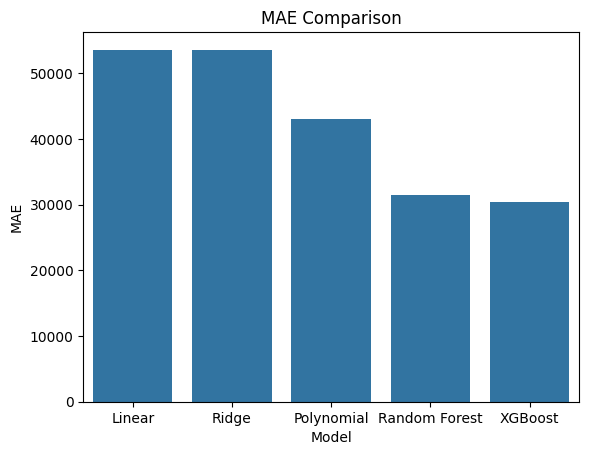

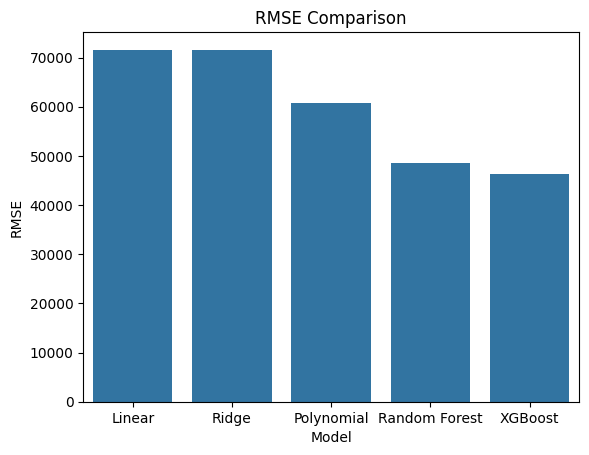

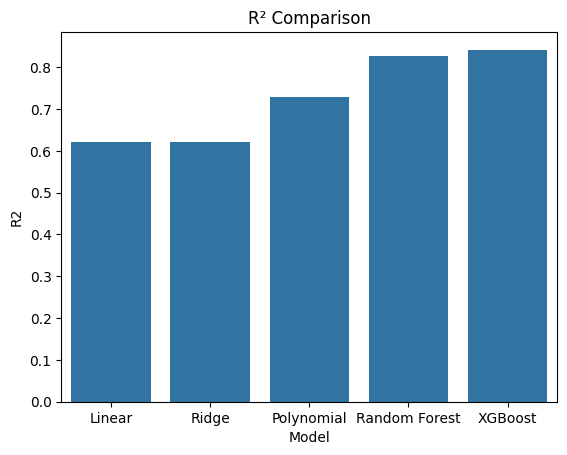

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear','Ridge', 'Polynomial', 'Random Forest', 'XGBoost'],
    'MAE': [mae, mae2, mae3, mae4, mae5],
    'RMSE': [rmse, rmse2, rmse3, rmse4, rmse5],
    'R2': [r2, r22, r23, r24, r25]
})
#MAE Comparision
sns.barplot(x='Model', y='MAE', data=results)
plt.title('MAE Comparison')
plt.show()

# RMSE comparison
sns.barplot(x='Model', y='RMSE', data=results)
plt.title('RMSE Comparison')
plt.show()

# R2 comparison
sns.barplot(x='Model', y='R2', data=results)
plt.title('R² Comparison')
plt.show()

**As We Can See In Bar Plots The RMSE and MAE Values Of XGBRegressor is least and R² Value Is Highest amongst these all So According to this Best Model Amongst These is XGBRegressor One.**